# CIFAR-10 Image Classification with Random Search Hyperparameter Tuning and Simple ResNet

Using TensorFlow and Keras Tuner, this notebook builds, tunes, trains, and evaluates a ResNet-inspired convolutional neural network (CNN) model on the CIFAR-10 dataset.

# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, Add, Activation, GlobalAveragePooling2D)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import keras_tuner as kt

TensorFlow/Keras for building the model.

Keras Tuner for hyperparameter search.

Matplotlib for plotting results.

sklearn for confusion matrix and evaluation metrics.

# Load and preprocess CIFAR-10 data

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


Normalize pixel values between 0 and 1.

One-hot encode the labels.

# Data augmentation pipeline

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


Apply random transformations to prevent overfitting and improve model generalization.

# Define a simple ResNet block

In [4]:
def resnet_block(inputs, filters, kernel_size=3, stride=1):
    x = Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    # Skip connection
    if stride != 1 or inputs.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(inputs)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = inputs

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

Two convolutional layers with skip connections.

If dimensions differ, apply a 1x1 convolution to the shortcut.

Adds stability and helps with gradient flow.

# Model building function for Hyperparameter Tuning

In [5]:
# Model building function
def build_model(hp):
    inputs = Input(shape=(32, 32, 3))

    x = data_augmentation(inputs)

    filters = hp.Int('filters_1', 32, 48, step=16)  # narrower range
    x = Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    num_blocks = hp.Int('num_blocks', 2, 2)  # fix to 2 blocks for speed
    for i in range(num_blocks):
        stride = 2 if i == 0 else 1
        filters_block = hp.Int(f'filters_block_{i}', filters, filters * 2, step=16)
        x = resnet_block(x, filters_block, stride=stride)

    x = GlobalAveragePooling2D()(x)

    dense_units = hp.Int('dense_units', 128, 256, step=64)  # narrower range
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(hp.Float('dropout_rate', 0.2, 0.3, step=0.1))(x)  # smaller dropout options

    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    learning_rate = hp.Choice('learning_rate', [1e-3, 1e-4])  # fewer choices
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

filters_1: First convolutional layer filters.

num_blocks: Number of ResNet blocks (fixed to 2).

filters_block_x: Filters per block.

dense_units: Number of neurons in the dense layer.

dropout_rate: Dropout rate to prevent overfitting.

learning_rate: Learning rate for optimizer.

# Setup Kereas Tuner such as RandomSearch tuner for faster, controlled search.

In [6]:
# Setup RandomSearch tuner for faster, controlled search
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  
    executions_per_trial=1,
    directory='my_dir',
    project_name='cifar10_tuning_resnet'
)


earlystop_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Calling back TensorBoard 
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# Searching for the best hyperparameters with 9 epochs per trial (10 was decided to speed up the tuning)
tuner.search(x_train, y_train,
             epochs=10,   
             validation_split=0.2,
             callbacks=[earlystop_cb],
             verbose=1)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
for param in best_hps.values.keys():
    print(f" - {param}: {best_hps.get(param)}")


Trial 26 Complete [00h 12m 25s]
val_accuracy: 0.6593999862670898

Best val_accuracy So Far: 0.7628999948501587
Total elapsed time: 18h 25m 26s

Best Hyperparameters:
 - filters_1: 32
 - num_blocks: 3
 - filters_block_0: 32
 - filters_block_1: 64
 - dense_units: 192
 - dropout_rate: 0.2
 - learning_rate: 0.001
 - filters_block_2: 64
 - tuner/epochs: 20
 - tuner/initial_epoch: 7
 - tuner/bracket: 2
 - tuner/round: 2
 - tuner/trial_id: 0015


# Build the best model, and Start Hyperparameter Search


In [7]:
model = tuner.hypermodel.build(best_hps)

# Save model architecture
with open('model_summary.txt', 'w', encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))


# Train final model with more epochs now that best hyperparameters are found
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb, tensorboard_cb],
    verbose=1
)


Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3244 - loss: 1.8064 - val_accuracy: 0.4324 - val_loss: 1.6612 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.5067 - loss: 1.3520 - val_accuracy: 0.5047 - val_loss: 1.4142 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.5654 - loss: 1.1957 - val_accuracy: 0.4433 - val_loss: 1.9892 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.5987 - loss: 1.1134 - val_accuracy: 0.4863 - val_loss: 1.5991 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.6364 - loss: 1.0274 - val_accuracy: 0.4413 - val_loss: 2.2364 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6735 - loss: 0.9205 - val_accuracy: 0.6541 - val_loss: 1.0154 - learning_rate: 5.0000e-04
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.6870

# Load full model with optimizer state from checkpoint

In [8]:
from tensorflow.keras.models import load_model

model = load_model('best_model.keras')

# Evaluate on test set

In [9]:

test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=64, verbose=1)
print(f"\nTest accuracy: {test_acc:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7889 - loss: 0.6107

Test accuracy: 0.7865


# Plot Accuracy and Loss

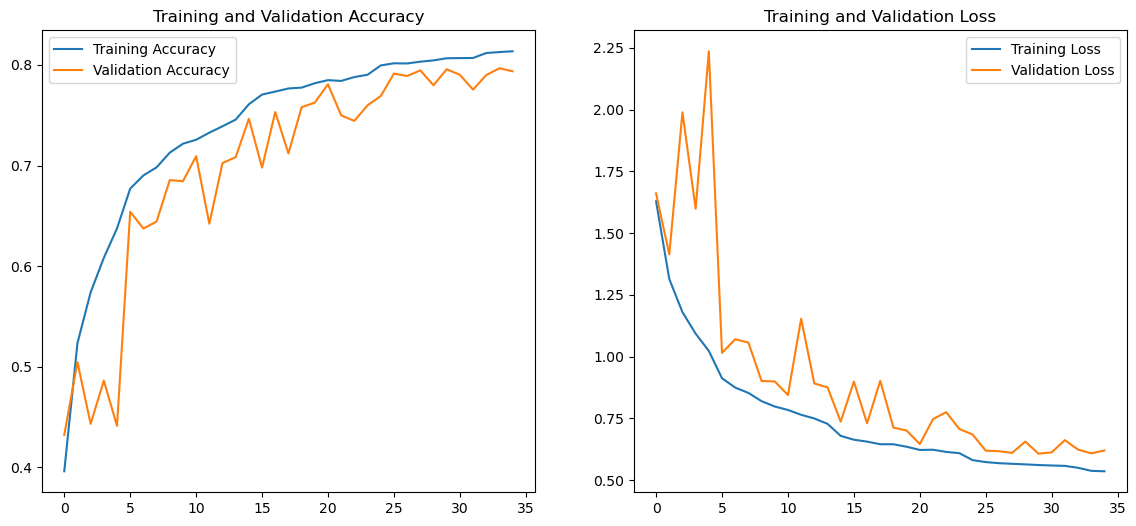

In [10]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


<Figure size 1000x1000 with 0 Axes>

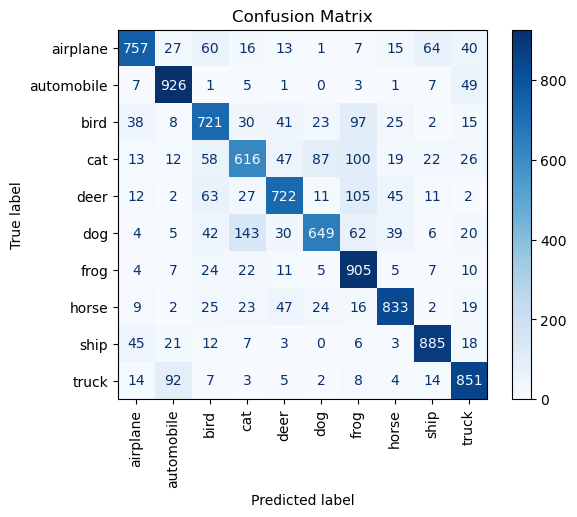

In [11]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Display some random predictions

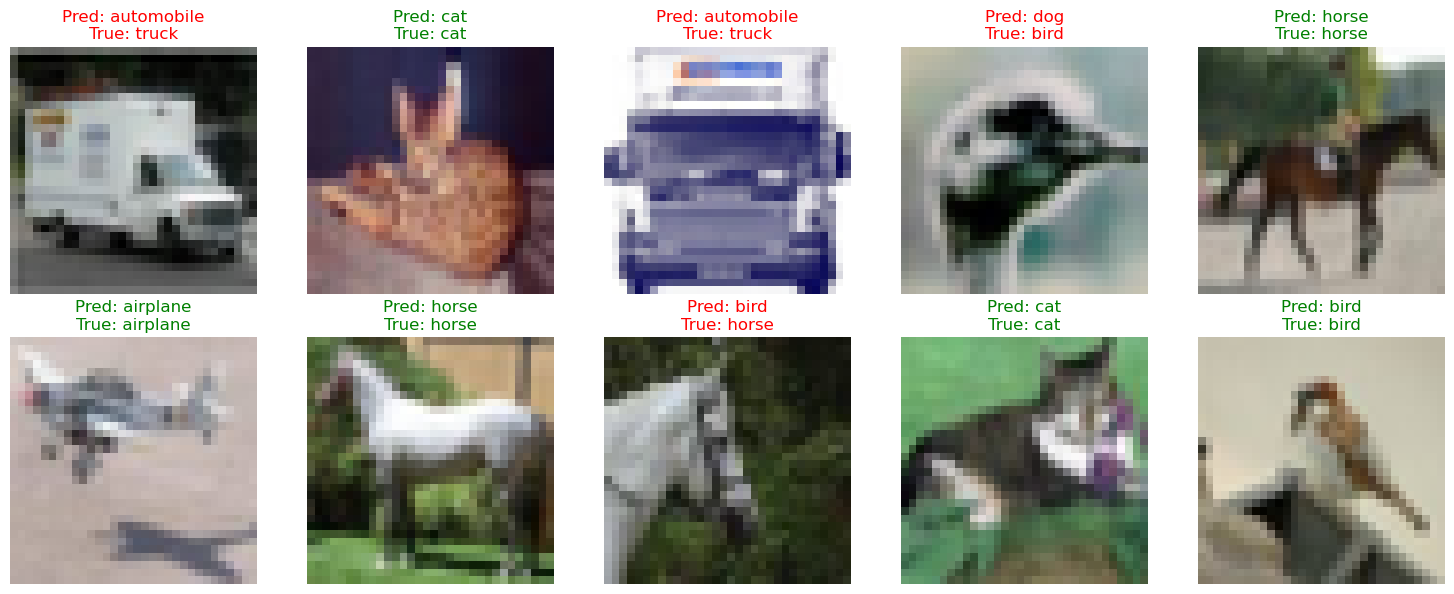

In [12]:
num_images = 10
indices = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(15,6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx])
    pred_label = class_names[y_pred_classes[idx]]
    true_label = class_names[y_true[idx]]
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import classification_report

# Predict
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)  
# Report
print(classification_report(y_true, y_pred_classes, target_names=class_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

    airplane       0.84      0.76      0.80      1000
  automobile       0.84      0.93      0.88      1000
        bird       0.71      0.72      0.72      1000
         cat       0.69      0.62      0.65      1000
        deer       0.78      0.72      0.75      1000
         dog       0.81      0.65      0.72      1000
        frog       0.69      0.91      0.78      1000
       horse       0.84      0.83      0.84      1000
        ship       0.87      0.89      0.88      1000
       truck       0.81      0.85      0.83      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000

